# Content-defined chunking & prolly trees, from the low bits up

A worked, runnable tour of the machinery behind history-independent chunk boundaries:
FNV-1a hashing, why only the **low bits** decide boundaries, **target size** (mask width),
**window size** (rolling hash), **MIN/MAX clamping**, and the **history-independence** these
choices buy you (or break).

Everything is computed live. Textbook constants are asserted so you can trust the rest.

## 0. Setup

Two universes of arithmetic appear below:

- **32-bit** exact modular arithmetic for the real FNV hash (`& 0xFFFFFFFF` after every multiply).
- **`mod 2^k`** shadow arithmetic — the whole point of the low-bits trick.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

MASK32 = 0xFFFFFFFF
np.random.seed(0)
plt.rcParams.update({"figure.figsize": (7, 3.2), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10})
print("ready")

ready


## 1. FNV-1a, the full 32-bit hash

One round per byte:

```
h ^= byte
h  = (h * PRIME) mod 2^32
```

with `seed = 0x811c9dc5` and `PRIME = 0x01000193` (= 16777619). We assert the textbook
value `FNV-1a("a") == 0xe40c292c` so everything downstream stands on solid ground.

In [2]:
FNV_OFFSET = 0x811c9dc5          # seed
FNV_PRIME  = 0x01000193          # 16777619 = 2^24 + 2^8 + 0x93

def fnv1a(data: bytes) -> int:
    h = FNV_OFFSET
    for b in data:
        h ^= b
        h = (h * FNV_PRIME) & MASK32
    return h

assert fnv1a(b"a") == 0xe40c292c            # textbook check
assert fnv1a(b"foobar") == 0xbf9cf968       # another textbook vector
print("FNV-1a('a')      =", hex(fnv1a(b"a")))
print("FNV-1a('foobar') =", hex(fnv1a(b"foobar")))

FNV-1a('a')      = 0xe40c292c
FNV-1a('foobar') = 0xbf9cf968


Our items are 32-bit integers, hashed as **little-endian** bytes (so key `k` is bytes
`[k&0xff, ...]`). This is the atom of the per-element tree.

In [3]:
def key_hash(k: int) -> int:
    return fnv1a(k.to_bytes(4, "little"))

# Example Stream 1 
print("Example stream 1:")
for k in (1, 2, 3, 5, 6, 7):
    print(f"key {k:2d} -> hash {key_hash(k):#010x}   (mod 4 = {key_hash(k) & 3})")

# Example Stream 2
print("Example stream 2:")
for k in (0, 1, 2, 3, 5, 6, 7, 544):
    print(f"key {k:3d} -> hash {key_hash(k):#010x}   (mod 4 = {key_hash(k) & 3})")

Example stream 1:
key  1 -> hash 0xfb69b604   (mod 4 = 0)
key  2 -> hash 0xebee7337   (mod 4 = 3)
key  3 -> hash 0x9bc23426   (mod 4 = 2)
key  5 -> hash 0xbab8b9c0   (mod 4 = 0)
key  6 -> hash 0xab3d76f3   (mod 4 = 3)
key  7 -> hash 0x5b1137e2   (mod 4 = 2)
Example stream 2:
key   0 -> hash 0x4b95f515   (mod 4 = 1)
key   1 -> hash 0xfb69b604   (mod 4 = 0)
key   2 -> hash 0xebee7337   (mod 4 = 3)
key   3 -> hash 0x9bc23426   (mod 4 = 2)
key   5 -> hash 0xbab8b9c0   (mod 4 = 0)
key   6 -> hash 0xab3d76f3   (mod 4 = 3)
key   7 -> hash 0x5b1137e2   (mod 4 = 2)
key 544 -> hash 0xd350709f   (mod 4 = 3)


## 2. The low bits are a sealed lane

**Claim.** To know `h mod 2^k` you never need the high bits — you can carry a value that's
only ever `0 .. 2^k-1` through the whole loop.

Two facts make this work:

- **XOR is bitwise** → the low `k` bits of `a ^ b` depend only on the low `k` bits of `a` and `b`.
- **Multiply is low-end-local mod 2^k**: writing `x = a + 2^k·A`, every cross term carries a
  factor `2^k` and vanishes, so `(x·P) mod 2^k = ((x mod 2^k)·(P mod 2^k)) mod 2^k`.

So a `mod 2^k` shadow of FNV-1a should agree with the real hash's low `k` bits — for every key,
every width. We check `k = 1..8` against 200 keys.

In [4]:
def low_bits_fnv(k: int, bits: int) -> int:
    mask = (1 << bits) - 1
    h = FNV_OFFSET & mask
    p = FNV_PRIME  & mask
    for b in k.to_bytes(4, "little"):
        h = ((h ^ (b & mask)) * p) & mask        # XOR then multiply, all mod 2^bits
    return h

for bits in range(1, 9):
    for k in range(0, 200):
        assert low_bits_fnv(k, bits) == key_hash(k) & ((1 << bits) - 1)
print("shadow(mod 2^k) == full_hash & (2^k-1)  for k=1..8, keys 0..199  ✓")

# the two constants the low-2-bit lane ever needs:
print("PRIME mod 4 =", FNV_PRIME % 4, "   seed mod 4 =", FNV_OFFSET % 4)
# and multiply-locality, spelled out:
assert all((x*FNV_PRIME) % 4 == ((x%4)*(FNV_PRIME%4)) % 4 for x in range(500))
print("(x·P) mod 4 == ((x mod 4)·(P mod 4)) mod 4  for x=0..499  ✓")

shadow(mod 2^k) == full_hash & (2^k-1)  for k=1..8, keys 0..199  ✓
PRIME mod 4 = 3    seed mod 4 = 1
(x·P) mod 4 == ((x mod 4)·(P mod 4)) mod 4  for x=0..499  ✓


## 3. Boundaries, and why they land on `k ≡ 1 (mod 4)`

The boundary test is `h & 3 == 0`, i.e. `h mod 4 == 0`. For these single-nonzero-byte keys the
shadow value after byte 0 just gets `×3` three more times, and `×3` is a bijection mod 4 that
fixes 0 — so a boundary happens **iff** the value was 0 after round 1, i.e. iff `k ≡ seed ≡ 1 (mod 4)`.
The code confirms the closed form for keys 1..20.

In [5]:
def is_boundary(k: int, bits: int = 2) -> bool:
    return (key_hash(k) & ((1 << bits) - 1)) == 0

keys = list(range(1, 21))
cuts_by_hash = [k for k in keys if is_boundary(k, 2)]
cuts_closed  = [k for k in keys if k % 4 == 1]
print("cut after (hash test) :", cuts_by_hash)
print("cut after (k%4 == 1)  :", cuts_closed)
assert cuts_by_hash == cuts_closed

# The congruence is NOT general — it rests on the key having a single nonzero
# byte, so it must break once keys reach 256. Find the first counterexample:
first_break = next(k for k in range(1, 10_000)
                   if is_boundary(k, 2) != (k % 4 == 1))
assert first_break >= 256
print(f"closed form matches for single-byte keys ✓ — and FAILS first at key "
      f"{first_break} (≥ 256, a second nonzero byte joins the hash)")


cut after (hash test) : [1, 5, 9, 13, 17]
cut after (k%4 == 1)  : [1, 5, 9, 13, 17]
closed form matches for single-byte keys ✓ — and FAILS first at key 257 (≥ 256, a second nonzero byte joins the hash)


Prolly trees are **sorted**; a chunk closes at each boundary key. The leaf partition of 1..20:

In [6]:
def partition(sorted_keys, bits=2):
    leaves, cur = [], []
    for k in sorted_keys:
        cur.append(k)
        if is_boundary(k, bits):
            leaves.append(cur); cur = []
    if cur:
        leaves.append(cur)
    return leaves

def print_leaves(input_keys, input_bits=2):
    for leaf in partition(input_keys, input_bits):
        print('\t%s'%leaf)

key_bits = 3 
print('Leaf Partitions example 1:')
print_leaves(keys, key_bits)

print('Leaf Partitions example 2')
print_leaves([1,2,3,4,5,6], key_bits)

print('Leaf Partitions example 3')
print_leaves([1,3,5,6], key_bits)



Leaf Partitions example 1:
	[1, 2, 3, 4, 5]
	[6, 7, 8, 9, 10, 11, 12, 13]
	[14, 15, 16, 17, 18, 19, 20]
Leaf Partitions example 2
	[1, 2, 3, 4, 5]
	[6]
Leaf Partitions example 3
	[1, 3, 5]
	[6]


## 4. Target size = 2^k (mask width sets the mean)

A `k`-bit zero test fires with probability `2^-k` per position, independent of the data (for a
good hash). Chunk length is therefore **geometric with mean `2^k`** and standard deviation ≈ mean
— a fat, high-variance tail. Below: empirical mean/std vs `2^k`, and a histogram against the
geometric pmf.

 k  target=2^k     mean      std
 4          16     16.1     15.5
 6          64     64.2     63.6
 8         256    262.6    263.9


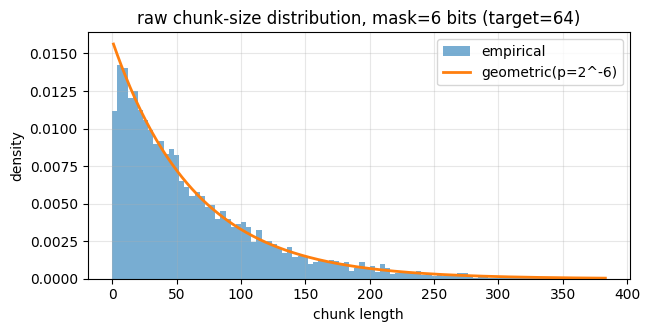

In [7]:
def raw_chunk_sizes(mask_bits, n=400_000, seed=1):
    rng = np.random.default_rng(seed)
    hit = rng.integers(0, 1 << mask_bits, size=n) == 0      # boundary at each position?
    idx = np.flatnonzero(hit)
    return np.diff(np.concatenate(([-1], idx)))             # gaps between boundaries

print(f"{'k':>2} {'target=2^k':>11} {'mean':>8} {'std':>8}")
for k in (4, 6, 8):
    s = raw_chunk_sizes(k)
    print(f"{k:>2} {1<<k:>11} {s.mean():>8.1f} {s.std():>8.1f}")

k = 6
s = raw_chunk_sizes(k)
plt.hist(s, bins=range(0, 6*(1<<k), 4), density=True, alpha=0.6, label="empirical")
xs = np.arange(1, 6*(1<<k))
p = 2.0**-k
plt.plot(xs, p*(1-p)**(xs-1), lw=2, label=f"geometric(p=2^-{k})")
plt.title(f"raw chunk-size distribution, mask={k} bits (target={1<<k})")
plt.xlabel("chunk length"); plt.ylabel("density"); plt.legend(); plt.show()

**Fanout = target.** The *same* test runs at every level, so target is the branching factor and
depth ≈ `log_{2^k}(N)`. Small target → fine dedup, small edit blast radius, but taller/bushier
tree and more per-node overhead. Large target → fewer nodes, cheaper metadata, coarser dedup,
bigger rewrites. `k` is chosen from desired entries-per-node (leaves ~32–128 → k ≈ 5–7).

## 5. MIN/MAX clamping (taming the tail)

Raw geometric emits size-1 runts and occasional giants. Clamp: suppress boundary tests until
`MIN` accumulated (kills runts), force a cut at `MAX` (kills giants). Expected size ≈ `MIN + 2^k`.

raw     : min=  1  max= 533  mean=  64.2  runts(<16)=20.5%
clamped : min= 16  max= 256  mean=  78.9  runts(<16)=0.0%   (MIN=16, MAX=256)


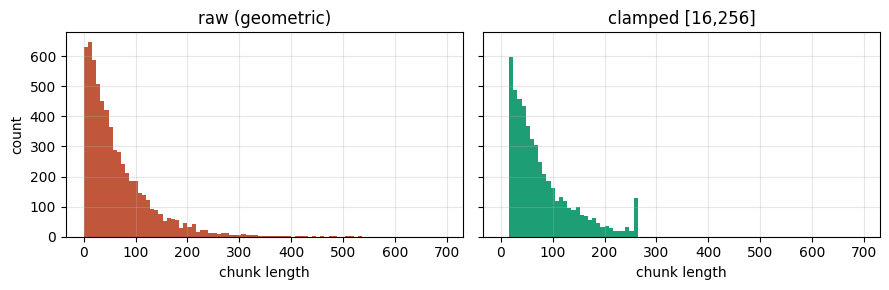

In [8]:
def clamped_sizes(mask_bits, MIN, MAX, n=400_000, seed=2):
    rng = np.random.default_rng(seed)
    hit = rng.integers(0, 1 << mask_bits, size=n) == 0
    sizes, run = [], 0
    for h in hit:
        run += 1
        if run >= MAX or (run >= MIN and h):
            sizes.append(run); run = 0
    if run:
        sizes.append(run)
    return np.array(sizes)

k, MIN, MAX = 6, 16, 256
raw = raw_chunk_sizes(k)
cl  = clamped_sizes(k, MIN, MAX)

print(f"raw     : min={raw.min():3d}  max={raw.max():4d}  mean={raw.mean():6.1f}  "
      f"runts(<{MIN})={np.mean(raw < MIN):.1%}")
print(f"clamped : min={cl.min():3d}  max={cl.max():4d}  mean={cl.mean():6.1f}  "
      f"runts(<{MIN})={np.mean(cl < MIN):.1%}   (MIN={MIN}, MAX={MAX})")

fig, ax = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
ax[0].hist(raw, bins=range(0, 700, 8), color="#c0563a"); ax[0].set_title("raw (geometric)")
ax[1].hist(cl,  bins=range(0, 700, 8), color="#1d9e75"); ax[1].set_title(f"clamped [{MIN},{MAX}]")
for a in ax: a.set_xlabel("chunk length")
ax[0].set_ylabel("count"); plt.tight_layout(); plt.show()

## 6. Window size (only for rolling-hash-over-bytes)

If you hash each **element** whole (sections 1–5), there is no window — the item is the atom.
A window appears only when you roll a hash across **serialized bytes**, where each decision
summarizes the last `W` bytes. Here's a cyclic-polynomial **buzhash**: rotate-left-1, XOR the
incoming byte's random word, XOR out the outgoing byte's word rotated by `W`.

In [9]:
def buzhash_boundaries(data: bytes, W=48, mask_bits=6, seed=42):
    tbl = np.random.default_rng(seed).integers(0, 1 << 32, size=256, dtype=np.uint64)
    tbl = [int(x) for x in tbl]
    mask = (1 << mask_bits) - 1
    Wr = W % 32
    h, outs = 0, []
    for i, b in enumerate(data):
        h = ((h << 1) | (h >> 31)) & MASK32          # rotate-left 1
        h ^= tbl[b]                                  # add incoming byte
        if i >= W:
            o = data[i - W]
            h ^= ((tbl[o] << Wr) | (tbl[o] >> (32 - Wr))) & MASK32   # remove outgoing
        h &= MASK32
        if i >= W and (h & mask) == 0:
            outs.append(i)
    return outs

data = np.random.default_rng(7).integers(0, 256, size=6000, dtype=np.uint8).tobytes()
b = buzhash_boundaries(data, W=48, mask_bits=6)
sizes = np.diff([0] + b)
print(f"{len(b)} boundaries, mean chunk = {sizes.mean():.1f}  (target 2^6 = 64)")

97 boundaries, mean chunk = 61.8  (target 2^6 = 64)


### Window = edit-healing distance

`W` is **not** the mean chunk size — that's still the mask. `W` is the decorrelation length. The
sharpest demonstration is an **insertion**: shove one byte in at offset 3000 and every downstream
byte shifts by one position. Fixed-size chunking would rewrite *everything* after the insert;
content-defined chunking re-syncs within ~`W` bytes because the rolling hash forgets the shift once
the inserted byte falls out of its window.

insert at 3000: downstream boundaries realign after a +1 shift within 58 bytes (W=48)
fraction of downstream boundaries that recover: 98%
→ a fixed-size scheme would have changed 100% of them


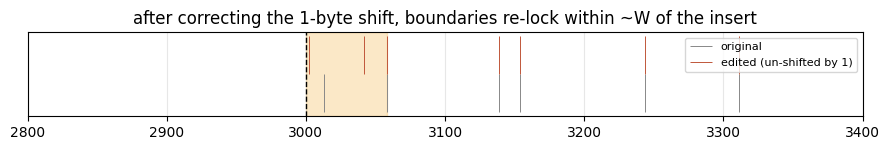

In [10]:
W = 48
ins = data[:3000] + bytes([0x5A]) + data[3000:]      # INSERT one byte -> downstream shifts by 1
b0 = buzhash_boundaries(bytes(data), W=W, mask_bits=6)
b1 = buzhash_boundaries(bytes(ins),  W=W, mask_bits=6)

# after the insert, an unchanged boundary at original offset x reappears at x+1
shifted = {x - 1 for x in b1 if x > 3000}
orig    = {x for x in b0 if x > 3000}
resync = next(x for x in sorted(orig) if all(y in shifted for y in sorted(orig) if y >= x))
print(f"insert at 3000: downstream boundaries realign after a +1 shift within "
      f"{resync-3000} bytes (W={W})")
print(f"fraction of downstream boundaries that recover: {len(shifted & orig)/len(orig):.0%}")
print("→ a fixed-size scheme would have changed 100% of them")

# visualize: plot edited boundaries shifted back by 1 so recovered ones overlap the originals
fig, ax = plt.subplots(figsize=(9, 1.6))
ax.vlines(sorted(orig), 0, 1, color="#888", lw=0.7, label="original")
ax.vlines([x - 1 for x in b1 if x > 3000], 1, 2, color="#c0563a", lw=0.7,
          label="edited (un-shifted by 1)")
ax.axvspan(3000, resync, color="#f2a623", alpha=0.25)
ax.axvline(3000, color="black", ls="--", lw=1)
ax.set_xlim(2800, 3400); ax.set_yticks([]); ax.legend(loc="upper right", fontsize=8)
ax.set_title("after correcting the 1-byte shift, boundaries re-lock within ~W of the insert")
plt.tight_layout(); plt.show()

Too-small `W` → under-mixed signal, degenerate on repetitive data. Too-large `W` → sluggish
boundaries, edits perturb more downstream chunks. Rule of thumb: `W ≈ 32–64 B`, always `≪ target`.

## 7. History independence (SIRI)

In the per-element scheme each key's boundary decision depends **only on its own hash**, so the
sorted leaf partition is identical no matter what order keys arrive in. This is the property that
gives byte-identical roots after shuffle-then-rebuild.

In [11]:
import random
ks = list(range(1, 401))
base = partition(sorted(ks), bits=3)
for trial in range(6):
    sh = ks[:]; random.Random(trial).shuffle(sh)
    assert partition(sorted(sh), bits=3) == base
print("shuffle -> sort -> identical partition, 6 trials  ✓  (history independent)")
print(f"{len(base)} leaves; first three sizes: {[len(x) for x in base[:3]]}")

shuffle -> sort -> identical partition, 6 trials  ✓  (history independent)
51 leaves; first three sizes: [5, 8, 8]


### The clamp caveat: a spectrum, not a switch

It's tempting to say "clamping breaks history-independence." The truth is more precise, and you can
measure it. The test: delete an early key and count how many leaves change. Pure content boundaries
give **exact** history-independence (one leaf moves). The more the *clamp* decides cuts rather than
the content, the more history-dependent you get — because a length counter counts from the previous
cut, and in the `MAX`-dominated limit that's just fixed-size chunking, where an early edit shifts
**everything** downstream.

In [12]:
def clamp_partition(sorted_keys, bits, MIN, MAX):
    leaves, cur = [], []
    for k in sorted_keys:
        cur.append(k)
        forced  = MAX is not None and len(cur) >= MAX
        natural = len(cur) >= MIN and is_boundary(k, bits)
        if forced or natural:
            leaves.append(cur); cur = []
    if cur:
        leaves.append(cur)
    return leaves

ks = list(range(1, 1001))
regimes = [
    ("pure content (no clamp)",     3, 1, None),
    ("gentle clamp (content-led)",  3, 4, 64),
    ("MAX-dominated (fixed-ish)",   8, 1, 16),
    ("pure fixed-size (MAX only)",  32, 1, 16),
]
print(f"{'regime':30s}{'leaves':>7}{'changed by deleting early key':>32}")
for name, bits, MIN, MAX in regimes:
    a = [tuple(x) for x in clamp_partition(ks, bits, MIN, MAX)]
    b = [tuple(x) for x in clamp_partition([k for k in ks if k != 3], bits, MIN, MAX)]
    changed = sum(1 for x in b if x not in a)
    print(f"{name:30s}{len(a):>7}{changed:>22} ({changed/len(a):.0%})")

regime                         leaves   changed by deleting early key
pure content (no clamp)           126                     1 (1%)
gentle clamp (content-led)        126                     1 (1%)
MAX-dominated (fixed-ish)          66                    13 (20%)
pure fixed-size (MAX only)         63                    63 (100%)


So gentle, content-led clamping (`MIN` small, `MAX` a loose safety net) keeps the blast radius at
essentially one leaf — the `MIN` suppression heals at the very next natural boundary, exactly like
the buzhash insert healed within `W`. It's `MAX`-forced cuts that reintroduce global dependence.

The fix if you need tight tails *and* exact history-independence: make the clamp decision
**deterministic from content within the window** (e.g. a secondary weak hash over local bytes to
pick the cut) instead of a raw length counter — so identical subsequences chunk identically no
matter what preceded them, preserving your byte-identical-root invariant.

## 8. Edit locality (blast radius)

Because only the edited region's boundaries move, inserting one key rewrites only the lea(f/ves)
around it — not the whole tree. We insert key `0` at the front and count changed leaves.

In [13]:
before = partition(sorted(ks), bits=3)
after  = partition(sorted(ks + [0]), bits=3)

bset = [tuple(x) for x in before]
aset = [tuple(x) for x in after]
changed = [x for x in aset if x not in bset]
print(f"leaves before: {len(before)}   after: {len(after)}")
print(f"leaves rewritten by inserting key 0 at the front: {len(changed)}  "
      f"({len(changed)/len(before):.1%} of the tree)")
print("first rewritten leaf:", changed[0])

leaves before: 126   after: 126
leaves rewritten by inserting key 0 at the front: 1  (0.8% of the tree)
first rewritten leaf: (0, 1, 2, 3, 4, 5)


## 9. What determines tree height?

Section 4 promised in prose that *depth ≈ log₂ₖ(N)* — compute it before building the levels.
The mechanism: the boundary test is the same at every level, so each level holds ~`N / 2^k`
chunks of the entries below it. Chunk counts shrink geometrically until one node remains, which
pins the height:

```
height H  ≈  ⌈ log_{2^k}(N) ⌉        (levels, leaf included)
```

Three claims fall out, each measurable:

1. **height grows with log N** and steps up only at ~`2^k`-multiplicative thresholds;
2. **height falls as k rises** — a bigger target means a bushier, shallower tree;
3. **the body concentrates, the top is noisy** — wide levels compress by ≈`2^k` because the
   noise averages over many chunks, but the top few levels hold too few entries for averaging
   and can tack on extra near-empty levels. Measured below — and it is exactly why the
   production engine carries a degenerate-internal-node guard (ADR-0069's
   `DegenerateInternalNodeGuardTest`).

Height is the read cost: a lookup (section 10) reads one node per level. So `k` — already the
mean chunk size *and* the fanout — is also the depth knob. Claim 1 first, with the prediction
alongside the measurement:

In [14]:
import math
import prolly_chunking as pc

def height(n_keys, bits=3):
    return len(pc.build_tree(list(range(1, n_keys + 1)), bits=bits))

print(f"{'N':>7} {'height':>7} {'⌈log_8 N⌉':>10}   (k=3, fanout 8)")
for n in (5, 30, 100, 300, 1000, 3000, 10000, 30000):
    h = height(n)
    pred = max(1, math.ceil(math.log(n) / math.log(8)))
    print(f"{n:>7} {h:>7} {pred:>10}   {'✓' if h == pred else '≈'}")

      N  height  ⌈log_8 N⌉   (k=3, fanout 8)
      5       1          1   ✓
     30       2          2   ✓
    100       3          3   ✓
    300       3          3   ✓
   1000       4          4   ✓
   3000       5          4   ≈
  10000       5          5   ✓


  30000       6          5   ≈


The prediction lands within ±1 everywhere — the slack is real, not sloppiness: near a threshold
the *content* decides whether the last handful of top-level entries happens to chunk into one
node or two. Which is also the answer to "what does an insert do to height?": nothing, almost
always. Only at a threshold does the tree grow, and growth is **adding a root above**, not
rewriting below — the one global-looking shape change is still an O(1) write.

Claim 2 — same N, sweep the mask:

In [15]:
N = 5000
print(f"{'k':>3} {'target=2^k':>11} {'mean leaf fanout':>17} {'height':>7} {'⌈log_2^k N⌉':>12}")
for k in (2, 3, 4, 5, 6):
    t = pc.build_tree(list(range(1, N + 1)), bits=k)
    fanout = N / len(t[0])
    pred = max(1, math.ceil(math.log(N) / (k * math.log(2))))
    print(f"{k:>3} {1 << k:>11} {fanout:>17.1f} {len(t):>7} {pred:>12}")

  k  target=2^k  mean leaf fanout  height  ⌈log_2^k N⌉
  2           4               4.0       8            7
  3           8               8.0       5            5
  4          16              15.9       3            4
  5          32              31.6       3            3
  6          64              62.5       2            3


Claim 3 — concentration, and where it fails. Forty different datasets of the same size (random
keys, so every tree chunks differently). The *body* of each tree compresses by ≈8 per level like
clockwork — but the heights still spread, because the **top** of the tree is a small-sample
regime: a level with five entries may split 5 → 3 → 2 → 1, spending three levels on almost no
compression. Look at both the spread and the level profile of the tallest tree:

In [16]:
from collections import Counter

heights, profiles = [], {}
for trial in range(40):
    keys = random.Random(trial).sample(range(1, 10_000_000), 2000)
    t = pc.build_tree(sorted(keys), bits=3)
    heights.append(len(t))
    profiles[len(t)] = [len(lv) for lv in t]

print(f"40 random datasets, N=2000, k=3 → height counts: {dict(sorted(Counter(heights).items()))}")
print(f"  ⌈log_8 2000⌉ = 4; median height {sorted(heights)[20]}")
tallest = max(profiles)
print(f"\nlevel profile of a height-{tallest} outlier: {profiles[tallest]}")
print("→ the wide levels compress by ≈8; the tail (…", profiles[tallest][-4:], "…) is the")
print("  small-sample top spending levels on tiny compressions — the 'degenerate top' that")
print("  production engines guard explicitly (the same test runs on 3 entries as on 2000)")

40 random datasets, N=2000, k=3 → height counts: {3: 2, 4: 23, 5: 14, 7: 1}
  ⌈log_8 2000⌉ = 4; median height 4

level profile of a height-7 outlier: [248, 36, 5, 2, 2, 2, 1]
→ the wide levels compress by ≈8; the tail (… [2, 2, 2, 1] …) is the
  small-sample top spending levels on tiny compressions — the 'degenerate top' that
  production engines guard explicitly (the same test runs on 3 entries as on 2000)


**Translating to the production engine** (order-of-magnitude arithmetic, not a measurement): the
byte-stream chunker targets ~4 KiB chunks, and an internal entry — a key plus a 20-byte child
address — serializes to a few dozen bytes, so internal fanout is on the order of 100. At that
fanout, a million leaf chunks sit under ~3 internal levels; heights stay in the single digits
until datasets are enormous, and every level is one chunk fetch on the lookup path. Now build
the levels and look inside them.

## 10. Multi-level trees, the Dolt way

Everything so far chunked one flat run of keys. Dolt's prolly tree applies the *same* trick
recursively, and that recursion is the whole data structure:

1. **Leaves**: chunk the sorted items by content (sections 1–8).
2. **Address each chunk** (hash of its serialized contents — 20 bytes here).
3. **Lift**: each chunk becomes one entry `(last key of chunk, chunk address)` in the level above.
4. **Chunk those entries with the same content-defined test**, and repeat until one node remains
   — the **root**, whose address names the entire dataset.

Two details carry the design. First, the lifted entry contains the child's *address*, so any
change anywhere percolates: parent bytes change → parent address changes → grandparent bytes
change — the Merkle spine. Second, each level's boundary decision hashes **key + address**
(not the key alone), so internal cuts don't align vertically with leaf cuts — the same
decorrelation job the production engine does with a per-level salt
(`BoundarySplitter.Factory.create(level)` in the Java engine hands each level its own seeded
splitter).

`prolly_chunking.build_tree` implements exactly this loop. Build one and look at its shape:

In [17]:
import prolly_chunking as pc

tree = pc.build_tree(sorted(ks), bits=3)          # ks = 1..1000 from section 7
print(f"{len(tree)} levels (leaf → root), target fanout 2^3 = 8\n")
for lvl, chunks in enumerate(tree):
    sizes = [len(c) for c in chunks]
    print(f"level {lvl}: {len(chunks):4d} nodes   "
          f"fanout mean {np.mean(sizes):4.1f}  min {min(sizes):2d}  max {max(sizes):3d}")

root = tree[-1][0]
print(f"\nroot node — {len(root)} entries of (last key of subtree, child address):")
for last_key, addr in root:
    print(f"  ≤ {last_key:4d} → {addr.hex()[:12]}…")
print(f"\nroot address (names the whole dataset): {pc.root_address(tree).hex()}")

4 levels (leaf → root), target fanout 2^3 = 8

level 0:  126 nodes   fanout mean  7.9  min  4  max   9
level 1:   13 nodes   fanout mean  9.7  min  1  max  25
level 2:    2 nodes   fanout mean  6.5  min  3  max  10
level 3:    1 nodes   fanout mean  2.0  min  2  max   2

root node — 2 entries of (last key of subtree, child address):
  ≤  884 → 5c09596c91a8…
  ≤ 1000 → ae932f19838b…

root address (names the whole dataset): cc31620d4231afd74657c27a80727f18a805be54


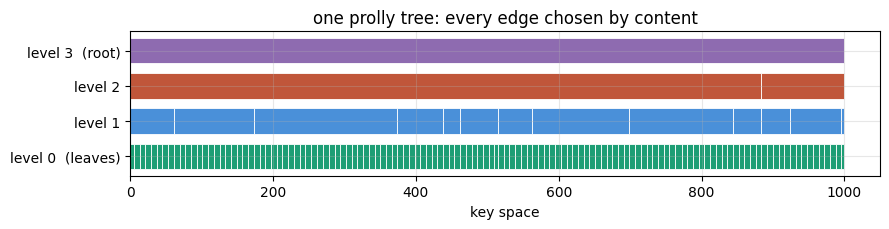

In [18]:
# The shape, drawn: one row per level, one rectangle per node, width = the
# key range the node covers. Content decides every edge you see.
fig, ax = plt.subplots(figsize=(9, 2.4))
colors = ["#1d9e75", "#4a90d9", "#c0563a", "#8e6bb0", "#b8860b"]
for lvl, chunks in enumerate(tree):
    prev = 0
    for node in chunks:
        last = node[-1][0]
        ax.barh(lvl, last - prev, left=prev, height=0.72,
                color=colors[lvl % len(colors)], edgecolor="white", lw=0.6)
        prev = last
ax.set_yticks(range(len(tree)))
ax.set_yticklabels([f"level {i}" + ("  (root)" if i == len(tree) - 1 else
                    "  (leaves)" if i == 0 else "") for i in range(len(tree))])
ax.set_xlabel("key space"); ax.set_title("one prolly tree: every edge chosen by content")
plt.tight_layout(); plt.show()

### Lookup is still a B-tree walk

Content decides the *shape*, but entries stay sorted, so search is untouched: at each internal
node, take the first entry whose last-key is ≥ the target and descend into its address. Depth is
`log_fanout(N)` — content-defined chunking cost you nothing on the read path:

In [19]:
def seek(tree, key):
    """Descend from the root; return the path of (level, key range) plus membership."""
    path, level, node = [], len(tree) - 1, tree[-1][0]
    while level > 0:
        path.append((level, node[0][0], node[-1][0]))
        idx = next((i for i, (last, _) in enumerate(node) if last >= key), len(node) - 1)
        addr = node[idx][1]
        node = next(c for c in tree[level - 1] if pc.chunk_address(c) == addr)
        level -= 1
    path.append((0, node[0][0], node[-1][0]))
    return path, any(k == key for k, _ in node)

for target in (487, 1001):
    path, found = seek(tree, target)
    hops = "  →  ".join(f"L{lvl}[{lo}..{hi}]" for lvl, lo, hi in path)
    print(f"seek({target}): {hops}   {'FOUND' if found else 'absent'}")

seek(487): L3[884..1000]  →  L2[61..884]  →  L1[470..515]  →  L0[487..494]   FOUND
seek(1001): L3[884..1000]  →  L2[924..1000]  →  L1[1000..1000]  →  L0[997..1000]   absent


### The spine rewrite, level by level

Section 8 counted total changed chunks; the per-level view shows the *shape* of an edit the way
Dolt sees it (its tree mutator collects exactly these "novel" nodes to persist). One insert
touches ~one node per level — the leaf it lands in plus the Merkle spine above it — and
occasionally two, when the insert moves a chunk boundary:

In [20]:
tree_after = pc.build_tree(sorted(ks + [0]), bits=3)
before_lvls, after_lvls = pc.level_addresses(tree), pc.level_addresses(tree_after)
total_new = 0
for lvl, (a, b) in enumerate(zip(before_lvls, after_lvls)):
    new = len(b - a); total_new += new
    print(f"level {lvl}: {new} of {len(b)} nodes novel")
print(f"→ persisting this edit writes {total_new} chunks "
      f"({total_new}/{sum(len(lv) for lv in after_lvls)} of the tree); "
      f"everything else is shared with the previous version by address")

level 0: 1 of 126 nodes novel
level 1: 2 of 14 nodes novel
level 2: 1 of 2 nodes novel
level 3: 1 of 1 nodes novel
→ persisting this edit writes 5 chunks (5/143 of the tree); everything else is shared with the previous version by address


### Structural sharing between versions

The payoff of the whole construction: because addresses are content-derived, *any* two trees
over overlapping data share chunks — not just a tree and its direct edit. A store that keeps
both versions stores the union of addresses, so history is cheap and diff can skip every shared
subtree by comparing a single address:

In [21]:
v1 = pc.build_tree(sorted(ks), bits=3)
v2_keys = sorted((set(ks) - set(range(400, 421))) | set(range(2000, 2051)))
v2 = pc.build_tree(v2_keys, bits=3)          # delete a range + append a range

a1, a2 = pc.tree_addresses(v1), pc.tree_addresses(v2)
print(f"v1: {len(a1)} chunks   v2: {len(a2)} chunks (21 keys deleted, 51 appended)")
print(f"shared: {len(a1 & a2)} chunks — storing both versions costs "
      f"{len(a1 | a2)} chunks, not {len(a1) + len(a2)}")
print(f"diff can prune every shared subtree at its address — the deeper the tree, "
      f"the bigger the skip")

v1: 142 chunks   v2: 147 chunks (21 keys deleted, 51 appended)
shared: 133 chunks — storing both versions costs 156 chunks, not 289
diff can prune every shared subtree at its address — the deeper the tree, the bigger the skip


**Mapping to the engine.** The Java implementation does exactly this loop with two substitutions:
entries are real key/value byte segments chunked by the rolling-hash splitter (not per-element
FNV), and level decorrelation comes from a per-level salt rather than address-mixing —
`BoundarySplitter.Factory.create(level)` hands every level its own seeded `RollingHashSplitter`.
[production_chunker.ipynb](production_chunker.ipynb) §5 builds this same multi-level tree with
the *faithful production port* and measures cross-edit chunk reuse there.

## 11. Commits: a Merkle DAG on top

Section 10 gave every *dataset* one 20-byte name — its root address. Version control is one more
layer of the same move: a **commit** is a tiny object that names a root **and its history**, and
the commit's own id is a hash of that object:

```
commit = { root: <tree root address>, parents: [<commit id>, …], message }
commit id = SHA-256(serialized commit)[:20]
```

Step by step, that hash buys the whole version-control feature set:

1. the id **commits to the data** (root address) *and* **to history** (parent ids) — tamper with
   either anywhere in the chain and every downstream id changes;
2. commits and chunks live in the **same content-addressed pool**, so a store holding many
   versions pays only for *novel* chunks (measured below);
3. **branches** are just named pointers to commit ids;
4. a merge commit has **two parents** — history is a directed acyclic graph, not a chain;
5. **diff prunes by address**: identical subtrees compare equal in O(1), so comparing two
   commits costs O(changed × depth), not O(N).

First, the commit object and a three-commit chain:

In [22]:
import hashlib, json as _json

STORE = {}                                   # one content-addressed pool: chunks AND commits

def commit(tree, parents, message):
    """Persist a tree's novel chunks + a commit object; return the commit id."""
    for lvl in tree:
        for chunk in lvl:
            STORE[pc.chunk_address(chunk)] = chunk          # dedup is free: same address, same slot
    obj = {"root": pc.root_address(tree).hex(),
           "parents": sorted(p.hex() for p in parents),
           "message": message}
    payload = _json.dumps(obj, sort_keys=True).encode()
    cid = hashlib.sha256(b"commit:" + payload).digest()[:20]
    STORE[cid] = obj
    return cid

def store_chunks():
    return sum(1 for v in STORE.values() if not isinstance(v, dict))

keys_v0 = list(range(1, 1001))
keys_v1 = sorted(set(keys_v0) | set(range(2000, 2051)))       # insert 50
keys_v2 = sorted(set(keys_v1) - set(range(400, 421)))         # then delete 21

sizes_before = 0
head = None
for keys, msg in [(keys_v0, "import 1..1000"),
                  (keys_v1, "append 2000..2050"),
                  (keys_v2, "drop 400..420")]:
    t = pc.build_tree(keys, bits=3)
    head = commit(t, [head] if head else [], msg)
    grew = store_chunks() - sizes_before; sizes_before = store_chunks()
    print(f"commit {head.hex()[:12]}…  \"{msg}\"  root {pc.root_address(t).hex()[:12]}…  "
          f"store +{grew} chunks (total {store_chunks()})")
print("\n→ each commit costs only its NOVEL chunks — history is structurally deduplicated")

commit 6be92070269e…  "import 1..1000"  root cc31620d4231…  store +142 chunks (total 142)
commit 38c394c7b972…  "append 2000..2050"  root 4877d769e1a3…  store +11 chunks (total 153)
commit 87f45d89057c…  "drop 400..420"  root d83ee973cc93…  store +4 chunks (total 157)

→ each commit costs only its NOVEL chunks — history is structurally deduplicated


### Step 2 — the id commits to history, not just data

Rebuild the *same* dataset with a *different* history and the root addresses agree (history
independence, section 7) — but the **commit ids differ**, because parents are inside the hash.
Data equality and history equality are separate questions, and the two hashes keep them
separate:

In [23]:
t_direct = pc.build_tree(keys_v2, bits=3)                    # same final data, no history
c_direct = commit(t_direct, [], "import final state directly")

print(f"same root?      {pc.root_address(t_direct) == pc.root_address(pc.build_tree(keys_v2, bits=3))}")
print(f"root (via edits) == root (direct import): "
      f"{STORE[head]['root'] == pc.root_address(t_direct).hex()}")
print(f"commit ids equal? {c_direct == head}   ← history differs, so ids differ")

same root?      True
root (via edits) == root (direct import): True
commit ids equal? False   ← history differs, so ids differ


### Step 3 — branches are pointers; the history is a DAG

A branch is a name → commit id entry, nothing more. Branch from the middle of the chain, make a
different edit, and there are two heads whose latest **common ancestor** is found by walking
parent ids — the input a three-way merge needs:

In [24]:
refs = {"main": head}

parent_of_head = bytes.fromhex(STORE[head]["parents"][0])
feature_keys = sorted(set(keys_v1) | set(range(5000, 5011)))     # diverge from commit 2
t_feat = pc.build_tree(feature_keys, bits=3)
refs["feature"] = commit(t_feat, [parent_of_head], "feature: add 5000..5010")

def ancestors(cid):
    out, todo = set(), [cid]
    while todo:
        c = todo.pop()
        if c in out: continue
        out.add(c)
        todo += [bytes.fromhex(p) for p in STORE[c]["parents"]]
    return out

common = ancestors(refs["main"]) & ancestors(refs["feature"])
base = max(common, key=lambda c: len(ancestors(c)))          # deepest common ancestor
print("refs:", {name: cid.hex()[:12] + "…" for name, cid in refs.items()})
print(f"merge base: {base.hex()[:12]}…  \"{STORE[base]['message']}\"")

refs: {'main': '87f45d89057c…', 'feature': '1f88b9bdd124…'}
merge base: 38c394c7b972…  "append 2000..2050"


### Step 4 — diff prunes by address

Two commits, two roots. Walk both trees top-down **skipping every address-equal subtree** — the
Merkle property means equal address ⇒ equal contents, recursively. The measurement is the point:
the walk touches O(changed × depth) nodes, not the whole tree:

In [25]:
def diff_keys(tree_a, tree_b):
    """Key sets added/removed between two trees — a level-wise frontier walk
    that prunes every shared address at EVERY level, so shared grandchildren
    under a differing parent still prune."""
    assert len(tree_a) == len(tree_b), "demo assumes equal height"
    idx_a = [{pc.chunk_address(c): c for c in lv} for lv in tree_a]
    idx_b = [{pc.chunk_address(c): c for c in lv} for lv in tree_b]
    fa = {pc.chunk_address(tree_a[-1][0])}
    fb = {pc.chunk_address(tree_b[-1][0])}
    visited = pruned = 0
    for lvl in range(len(tree_a) - 1, -1, -1):
        shared = fa & fb
        pruned += len(shared)                    # equal address ⇒ identical subtree: skip it
        fa -= shared; fb -= shared
        visited += len(fa) + len(fb)
        if lvl == 0:
            break
        fa = {addr for a in fa for _, addr in idx_a[lvl][a]}
        fb = {addr for b in fb for _, addr in idx_b[lvl][b]}
    ka = {k for a in fa for k, _ in idx_a[0][a]}
    kb = {k for b in fb for k, _ in idx_b[0][b]}
    return kb - ka, ka - kb, visited, pruned

t_main = pc.build_tree(keys_v2, bits=3)
add, rem, visited, pruned = diff_keys(pc.build_tree(keys_v1, bits=3), t_main)
total_nodes = sum(len(lv) for lv in t_main)
print(f"diff(commit 2 → commit 3): +{len(add)} keys, -{len(rem)} keys")
print(f"differing nodes visited: {visited}, shared subtrees pruned: {pruned} "
      f"(tree has {total_nodes} nodes) → O(changed × depth), not O(N)")
assert rem == set(range(400, 421)) and add == set()
assert visited < total_nodes // 2               # the walk must actually beat O(N)


diff(commit 2 → commit 3): +0 keys, -21 keys
differing nodes visited: 10, shared subtrees pruned: 15 (tree has 147 nodes) → O(changed × depth), not O(N)


### Step 5 — a merge commit: two parents, one new root

Three-way merge over key sets: take the base, apply *both* sides' adds and deletes (diffs
computed with the pruning walk above), build the merged tree, and commit it with **two
parents**. The history is now a genuine DAG — and the merged tree again shares almost all of
its chunks with both sides:

In [26]:
t_base = pc.build_tree(keys_v1, bits=3)

add_m, rem_m, *_ = diff_keys(t_base, t_main)
add_f, rem_f, *_ = diff_keys(t_base, t_feat)
merged_keys = sorted((set(keys_v1) | add_m | add_f) - rem_m - rem_f)
t_merged = pc.build_tree(merged_keys, bits=3)

before = store_chunks()
merge_id = commit(t_merged, [refs["main"], refs["feature"]], "merge feature into main")
refs["main"] = merge_id

shared_main = len(pc.tree_addresses(t_merged) & pc.tree_addresses(t_main))
shared_feat = len(pc.tree_addresses(t_merged) & pc.tree_addresses(t_feat))
n = len(pc.tree_addresses(t_merged))
print(f"merge commit {merge_id.hex()[:12]}…  parents: "
      f"{[p[:12] + '…' for p in STORE[merge_id]['parents']]}")
print(f"merged tree: {n} chunks — {shared_main} shared with main, {shared_feat} with feature; "
      f"store grew by only {store_chunks() - before} chunks")
assert set(merged_keys) == (set(keys_v2) | set(range(5000, 5011)))

merge commit a17238e1f8c8…  parents: ['1f88b9bdd124…', '87f45d89057c…']
merged tree: 148 chunks — 143 shared with main, 144 with feature; store grew by only 1 chunks


**Mapping to the engine.** This is the storage model of the Java engine end to end: prolly-tree
chunks and commit objects share one content-addressed store; branches are refs; a commit's
20-byte id commits to root + parents. Two engine behaviors follow directly from what this
section measured: **garbage collection** keeps exactly the closure reachable from commits
(orphaned chunks — aborted writes, crash residue — are the only thing swept), and **sync**
ships the address-closure difference between two heads, then converges replicas to
byte-identical roots — which only works because the tree's shape is history-independent
(section 7). The engine's [hash-function study](../docs/write-ups/hash-function-study.md)
is about the digest behind these addresses; the boundary function (this notebook) decides
*what* gets addressed.

## Summary

| knob | set by | controls | regime |
|---|---|---|---|
| **target size** | mask width `k` → `2^k` | mean chunk size = fanout = tree depth | always |
| **MIN / MAX** | clamp thresholds | tail shape (kills runts/giants) | always; naive form breaks SIRI |
| **window `W`** | rolling-hash span | edit-healing distance / decorrelation | byte-stream only |

- Only the **low `k` bits** decide boundaries; they carry as a sealed `mod 2^k` computation.
- **Target** is the mean and the fanout; **window** is the blast radius — different axes.
- **History independence** is free in per-element hashing, and must be *defended* when you clamp.